## Model Price vs. Spare Capacity Metric

In [72]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

GEN_PATH = '../../01_data/2_cleaned/generation/hourly_solar_wind_generation_2020_2025.parquet'
LOAD_PATH = '../../01_data/2_cleaned/load/total_load_20201231_20260526.csv'
CAPACITY_PATH = '../../01_data/2_cleaned/generation/ERCOT nonRE capacity 2020-2025.csv'
PRICE_PATH = '../../01_data/2_cleaned/rtm_price/rtm_price_aggregated_2021_2025.csv'
NG_PATH = '../../01_data/3_analysis/ng_price/ng_prices_monthly.csv'
TEMP_PATH = '../../01_data/2_cleaned/weather/Texas daily average temp HDD CDD 2020-2025.csv'

OUT_DIR = Path('../../01_data/3_analysis/price incentive metrics')

In [73]:
# import datasets
df_gen = pd.read_parquet(GEN_PATH)
df_gen['datetime'] = pd.to_datetime(df_gen['datetime'])
df_gen.head()

,datetime,renewable_gen
0,2020-01-01 01:00:00,12832.85
1,2020-01-01 02:00:00,13328.73
2,2020-01-01 03:00:00,13920.06
3,2020-01-01 04:00:00,14443.91
4,2020-01-01 05:00:00,14713.70


In [74]:
df_load = pd.read_csv(LOAD_PATH)
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_load.head()

,datetime,total_load
0,2020-12-31 01:00:00,39174.39
1,2020-12-31 02:00:00,38284.84
2,2020-12-31 03:00:00,37776.69
3,2020-12-31 04:00:00,37781.84
4,2020-12-31 05:00:00,38455.69


In [75]:
df_capacity = pd.read_csv(CAPACITY_PATH)
df_total_cap = df_capacity.filter(['year', 'total_mw'])
df_total_cap = df_total_cap.rename(columns={'total_mw': 'non_re_capacity'})
df_total_cap['non_re_capacity'] = df_total_cap['non_re_capacity'].astype(int)
df_total_cap

,year,non_re_capacity
0,2020,65518
1,2021,66390
2,2022,67023
3,2023,68028
4,2024,68766
5,2025,68624


In [76]:
df_price = pd.read_csv(PRICE_PATH)
df_price = df_price.filter(['date_time', 'avg_rtm_price'])
df_price = df_price.rename(columns={'date_time': 'datetime', 'avg_rtm_price' : 'rtm_price'})
df_price['datetime'] = pd.to_datetime(df_price['datetime'])
df_price.describe()

,datetime,rtm_price
count,43315,43315.000000
mean,2023-07-02 13:27:46.729770,66.584313
min,2021-01-01 01:00:00,-2.656667
25%,2022-04-03 07:30:00,19.183333
50%,2023-07-05 13:00:00,27.560000
75%,2024-09-29 18:30:00,43.636000
max,2025-12-28 00:00:00,9001.180667
std,NaN,418.440833


In [77]:
df_ng = pd.read_csv(NG_PATH)
df_ng = df_ng[(df_ng['date']>= '2021-01-01') & (df_ng['date']<= '2025-12-01')]
df_ng['date'] = pd.to_datetime(df_ng['date'])
df_ng['month'] = df_ng['date'].dt.month
df_ng['year'] = df_ng['date'].dt.year

df_ng.head()

,date,henry_hub,citygate,elec_pwr,outlier_citygate,outlier_elec_pwr,month,year
227,2021-01-01,2.712632,2.909441,2.793834,False,False,1,2021
228,2021-02-01,5.353684,39.181118,59.614644,True,True,2,2021
229,2021-03-01,2.618261,4.393064,2.947977,False,False,3,2021
230,2021-04-01,2.662857,3.554913,3.131021,False,False,4,2021
231,2021-05-01,2.912500,3.429672,3.294798,False,False,5,2021


In [78]:
df_temp = pd.read_csv(TEMP_PATH)
df_temp

,date,avg_temp_f,HDD,CDD
0,2020-01-01,48.757951,16.242049,0.000000
1,2020-01-02,51.860638,13.139362,0.000000
2,2020-01-03,47.237173,17.762827,0.000000
3,2020-01-04,49.566775,15.433225,0.000000
4,2020-01-05,52.088283,12.911717,0.000000
...,...,...,...,...
2187,2025-12-27,71.011770,0.446098,6.457868
2188,2025-12-28,57.002096,8.901164,0.903260
2189,2025-12-29,39.680961,25.319039,0.000000
2190,2025-12-30,43.390938,21.609062,0.000000


### Metric 1: spare capacity calculation
1. exclude uri points ()
2. metric1: evaluates spare capacity; 
    - closer to 1: load >> capacity limit
    - heat wave drives up load or data center demand increase

In [79]:
import duckdb
con = duckdb.connect()
df_metric = con.execute("""
   WITH Merged AS (
      SELECT
         g.datetime
         ,rtm_price
         ,renewable_gen
         ,total_load
         ,non_re_capacity
      FROM df_gen g
      INNER JOIN df_load l ON g.datetime = l.datetime
      LEFT JOIN df_total_cap c ON YEAR(g.datetime) = c.year
      JOIN df_price p ON g.datetime = p.datetime
      WHERE CAST(g.datetime AS DATE) <= '2021-02-13' OR CAST(g.datetime AS DATE) >= '2021-02-25'                 
      )
   
   SELECT
         datetime
         ,YEAR(datetime) AS year
         ,rtm_price
         ,(total_load - renewable_gen)/non_re_capacity AS metric1
   FROM Merged
   ORDER BY datetime;
""").fetchdf()

df_metric

,datetime,year,rtm_price,metric1
0,2021-01-01 01:00:00,2021,18.714000,0.447794
1,2021-01-01 02:00:00,2021,18.107333,0.437193
2,2021-01-01 03:00:00,2021,17.570000,0.434211
3,2021-01-01 04:00:00,2021,17.670667,0.449278
4,2021-01-01 05:00:00,2021,17.792000,0.470151
...,...,...,...,...
43025,2025-12-27 20:00:00,2025,17.682000,0.393060
43026,2025-12-27 21:00:00,2025,15.002667,0.374186
43027,2025-12-27 22:00:00,2025,13.227333,0.369187
43028,2025-12-27 23:00:00,2025,14.328667,0.349536


In [80]:
import statsmodels.api as sm
def lowess_fit(x, y, color, year):
    
    # 2. Apply LOWESS local regression
    # frac: the fraction of data used when estimating each y-value (controls smoothing)
    lowess_fit = sm.nonparametric.lowess(y, x, frac=0.1)

    # Extract sorted x and predicted y values
    x_smooth = lowess_fit[:, 0]
    y_smooth = lowess_fit[:, 1]

    # plot
    plt.scatter(x, y, color='lightgray')
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2, label=f"{year} LOWESS Fit")
    plt.legend()

/Users/zyliazhang/Git/ERCOT-Research/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


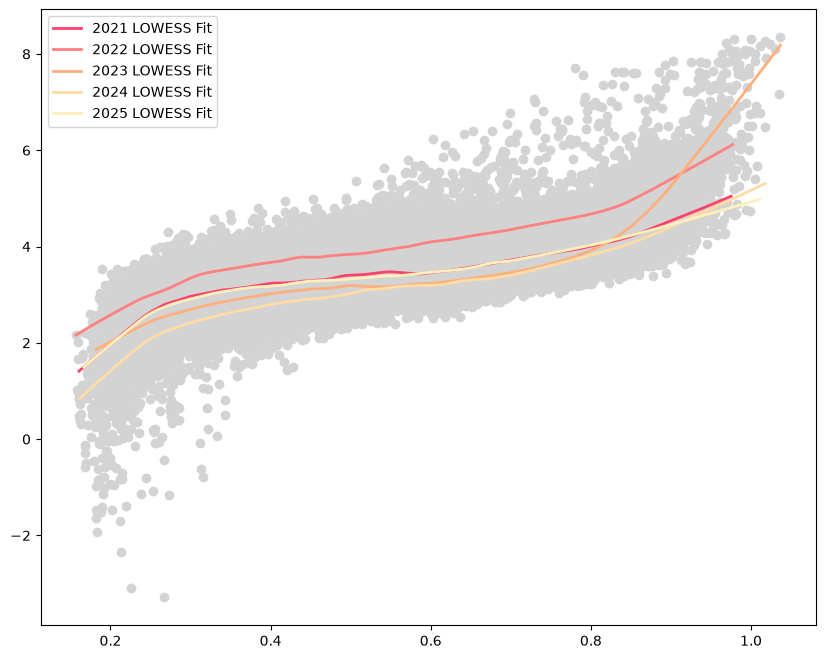

In [81]:
fig, ax = plt.subplots(figsize=(10, 8))
years = [2021, 2022, 2023, 2024, 2025]
colors = ['#FF416C', '#FF8080', '#FFAF7B', '#FFDCA6', '#FFEFBA']

for year, color in zip(years, colors):
    df_year = df_metric[df_metric['year'] == year]
    lowess_fit(df_year['metric1'], np.log(df_year['rtm_price']), color, year)

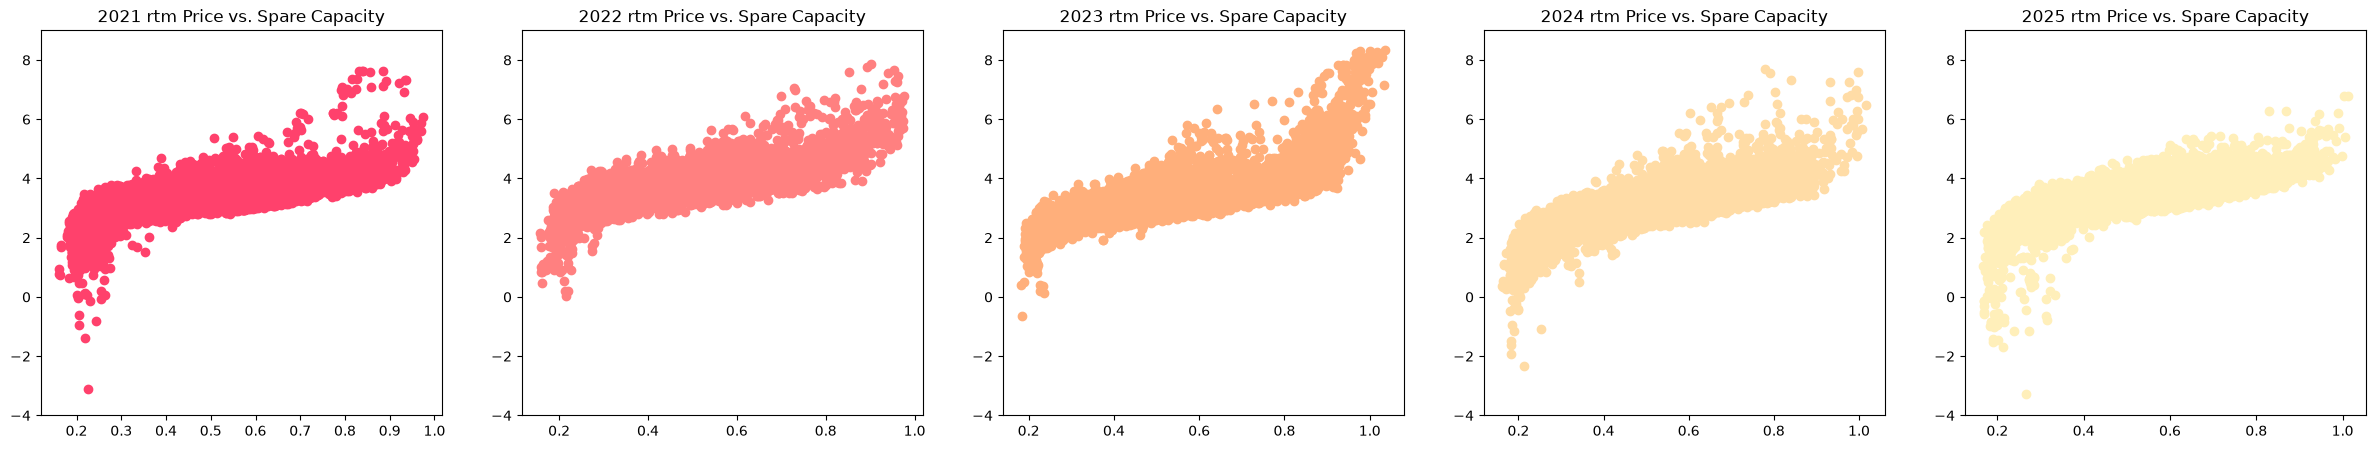

In [82]:
fig, axs = plt.subplots(1, 5, figsize=(30, 5))
for i, year in enumerate(years):
    df_year = df_metric[df_metric['year'] == year]
    axs[i].scatter(df_year['metric1'], np.log(df_year['rtm_price']), color=colors[i])
    axs[i].set_ylim(-4, 9)
    axs[i].set_title(f'{year} rtm Price vs. Spare Capacity')

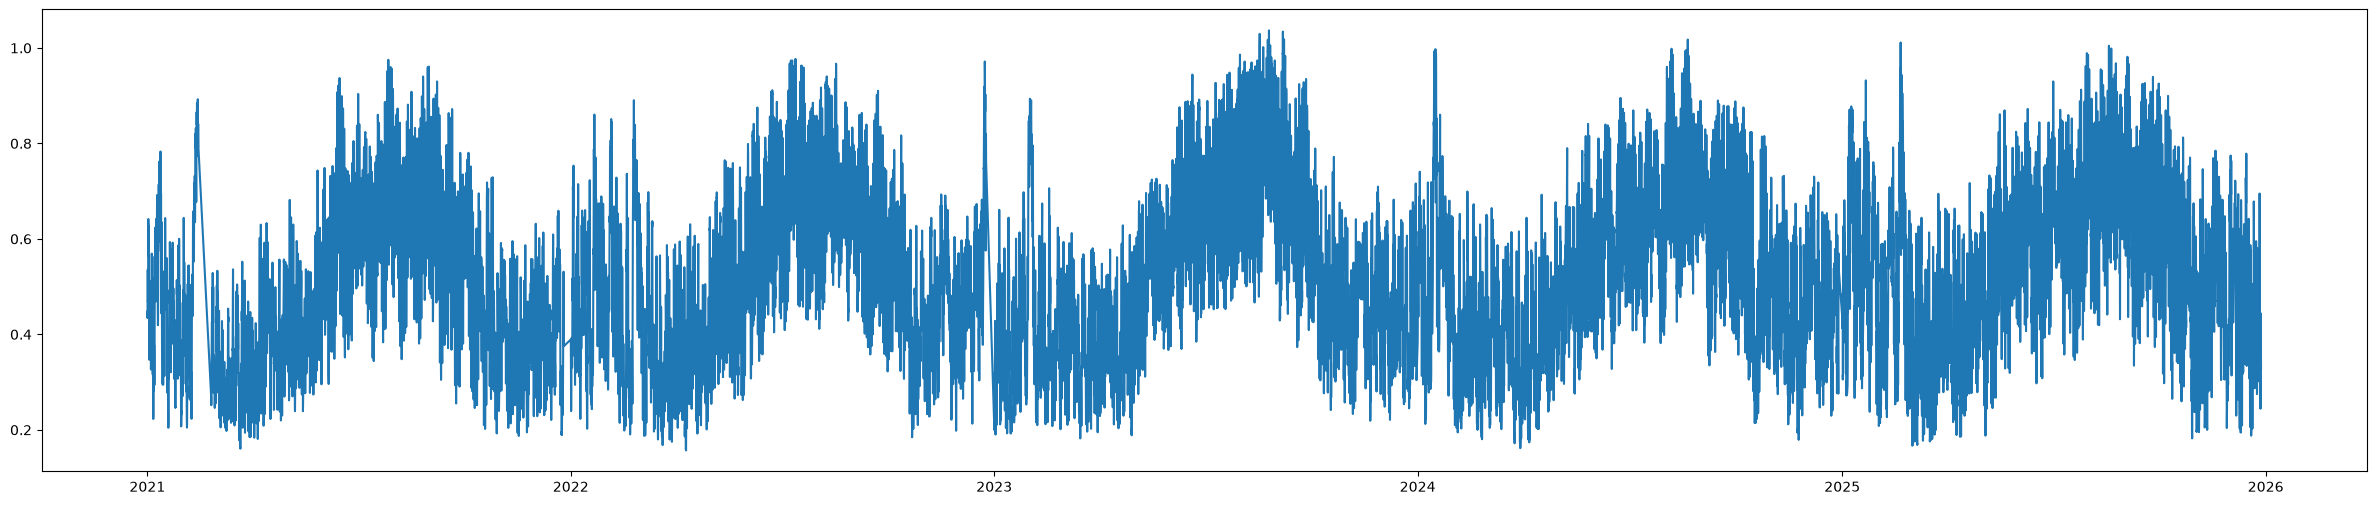

In [83]:
fig, ax = plt.subplots(figsize=(30, 6))
ax.plot(df_metric['datetime'] , df_metric['metric1'])

### Natural Gas color coding

In [89]:
df_metric_with_ng = con.execute("""
      SELECT 
         m.datetime
         ,rtm_price
         ,metric1 AS capacity
         ,citygate AS ng_price
      FROM df_metric m
         LEFT JOIN df_ng n ON n.month = MONTH(m.datetime)
                           AND n.year = m.year                         
      ORDER BY n.year, n.month;
""").fetchdf()

df_metric_with_ng

,datetime,rtm_price,capacity,ng_price
0,2021-01-01 01:00:00,18.714000,0.447794,2.909441
1,2021-01-01 02:00:00,18.107333,0.437193,2.909441
2,2021-01-01 03:00:00,17.570000,0.434211,2.909441
3,2021-01-01 04:00:00,17.670667,0.449278,2.909441
4,2021-01-01 05:00:00,17.792000,0.470151,2.909441
...,...,...,...,...
43025,2025-12-27 20:00:00,17.682000,0.393060,4.065511
43026,2025-12-27 21:00:00,15.002667,0.374186,4.065511
43027,2025-12-27 22:00:00,13.227333,0.369187,4.065511
43028,2025-12-27 23:00:00,14.328667,0.349536,4.065511


Text(0.5, 1.0, 'RTM Price (Log) vs. Spare Capacity colored by NG Price (Log)\n2021-2025')

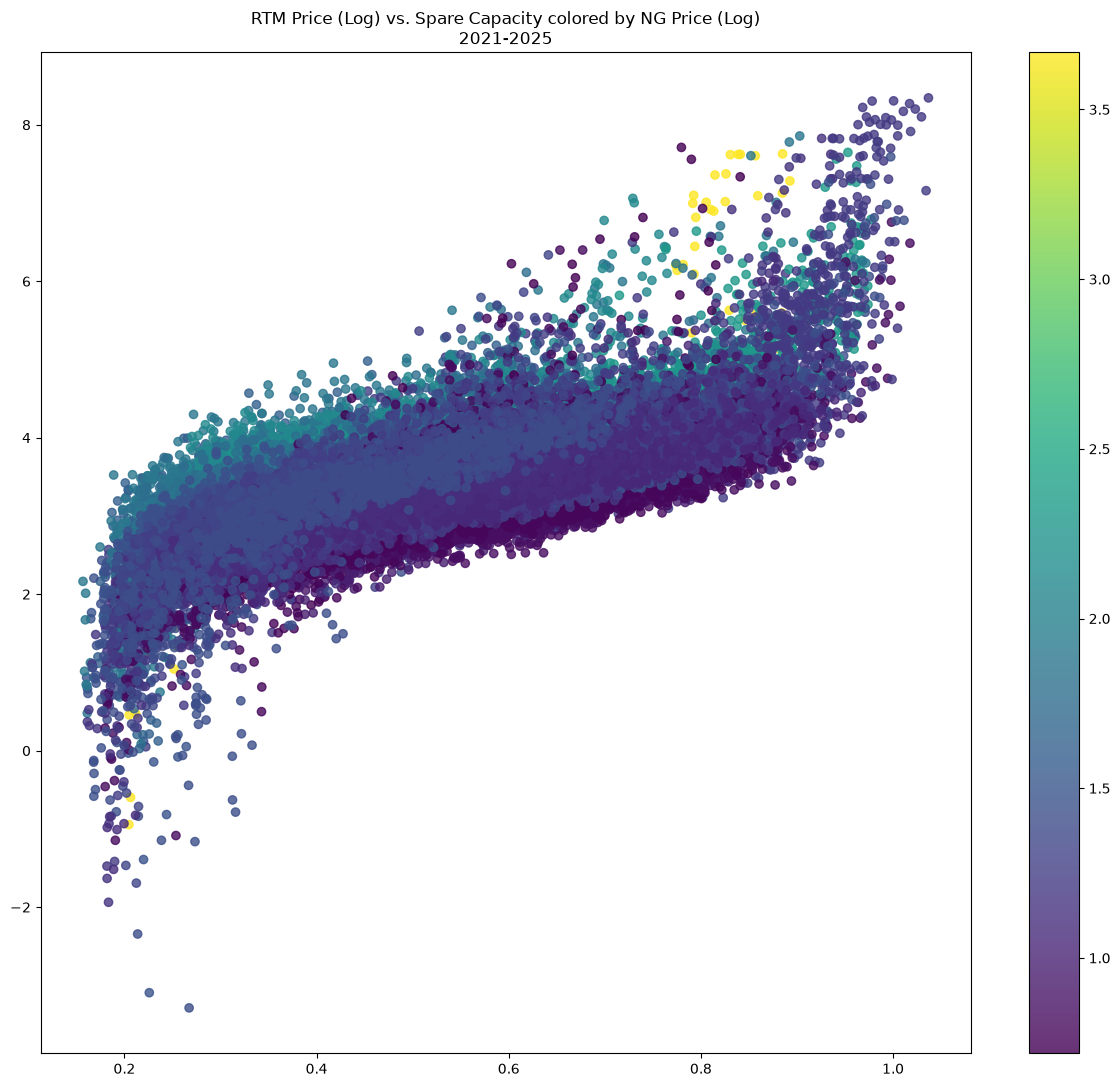

In [102]:
df = df_metric_with_ng.copy()
plt.figure(figsize=(15, 13))
plt.scatter(df['capacity'], np.log(df['rtm_price']), c=np.log(df['ng_price']), alpha=0.8)
plt.colorbar()
plt.title('RTM Price (Log) vs. Spare Capacity colored by NG Price (Log)\n2021-2025')

### Temp Color Coding

In [95]:
df_metric_with_temp = con.execute("""
      SELECT 
         m.datetime
         ,ABS(avg_temp_f - 65) AS degree_days
         ,rtm_price
         ,metric1 AS capacity
      FROM df_metric m
         LEFT JOIN df_temp t ON t.date = CAST(m.datetime AS DATE)                        
      ORDER BY m.datetime;
""").fetchdf()
df_metric_with_temp

,datetime,degree_days,rtm_price,capacity
0,2021-01-01 01:00:00,26.396616,18.714000,0.447794
1,2021-01-01 02:00:00,26.396616,18.107333,0.437193
2,2021-01-01 03:00:00,26.396616,17.570000,0.434211
3,2021-01-01 04:00:00,26.396616,17.670667,0.449278
4,2021-01-01 05:00:00,26.396616,17.792000,0.470151
...,...,...,...,...
43025,2025-12-27 20:00:00,6.011770,17.682000,0.393060
43026,2025-12-27 21:00:00,6.011770,15.002667,0.374186
43027,2025-12-27 22:00:00,6.011770,13.227333,0.369187
43028,2025-12-27 23:00:00,6.011770,14.328667,0.349536


Text(0.5, 1.0, 'RTM Price vs. Spare Capacity (colored by |Temp - 65|)\n2021-2025')

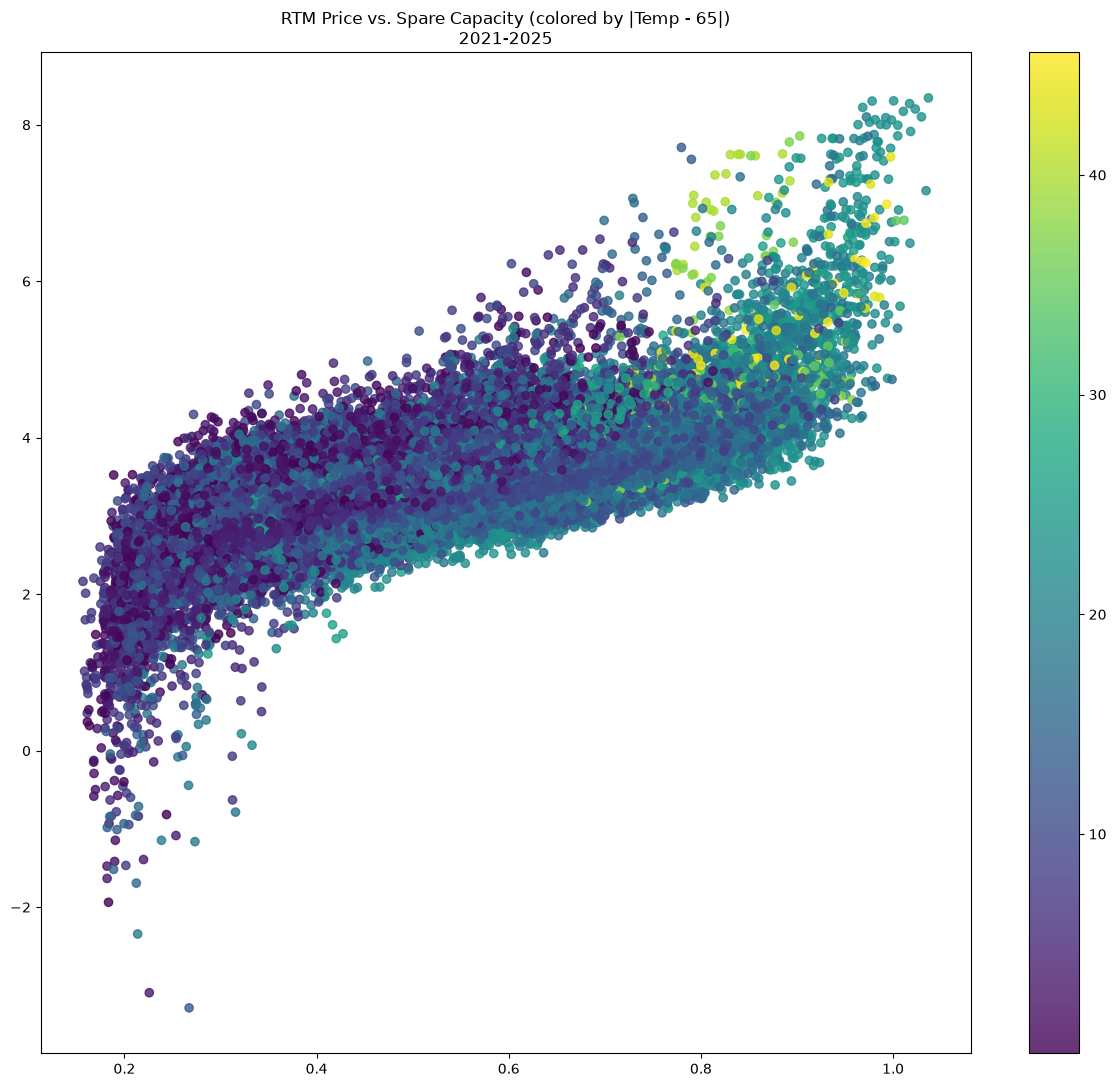

In [103]:
df = df_metric_with_temp.copy()
plt.figure(figsize=(15, 13))
plt.scatter(df['capacity'], np.log(df['rtm_price']), c=df['degree_days'], alpha=0.8)
plt.colorbar()
plt.title('RTM Price vs. Spare Capacity (colored by |Temp - 65|)\n2021-2025')